# SinFusion — Test sur OVHCloud JupyterLab
**Projet** : Single-Source Fast Generation (GENAI ING3)

## 1. Setup

In [1]:
import os, subprocess, sys

# Racine du projet (parent du dossier notebooks/)
PROJECT_ROOT = os.path.dirname(os.path.abspath(''))
os.chdir(PROJECT_ROOT)
print(f"Répertoire : {PROJECT_ROOT}")

Répertoire : /workspace/Projet_GenAI


In [2]:
# Lancer le script de setup (installe PyTorch cu118, dépendances, init submodule)
!bash setup.sh

 Single-Source Fast Generation — Setup

[0/5] Correction de PyTorch...
  Driver CUDA détecté : 12.8
Found existing installation: torch 2.11.0
Uninstalling torch-2.11.0:
  Successfully uninstalled torch-2.11.0
Found existing installation: torchvision 0.26.0
Uninstalling torchvision-0.26.0:
  Successfully uninstalled torchvision-0.26.0
Found existing installation: torchaudio 2.11.0
Uninstalling torchaudio-2.11.0:
  Successfully uninstalled torchaudio-2.11.0
  PyTorch 2.6.0+cu118 installé.

[1/5] Vérification GPU...
  PyTorch         : 2.6.0+cu118
  CUDA disponible : True
  GPU             : Tesla V100S-PCIE-32GB
  VRAM            : 34.1 GB

[2/5] Initialisation du submodule SinFusion...
  SinFusion disponible dans ./sinfusion/

[3/5] Installation des dépendances...
  Dépendances installées.

[4/5] Vérification SinFusion...
  NextNet              : OK
  Diffusion            : OK
  ConditionalDiffusion : OK

[5/5] Création des dossiers...

 Setup terminé avec succès !

 Lance l'entraînemen

## 2. Préparer l'image source

SinFusion attend les images dans `sinfusion/images/`.  
On télécharge `fruit.png` (fournie par les auteurs dans le repo officiel).

Image déjà présente : sinfusion/images/fruit.png


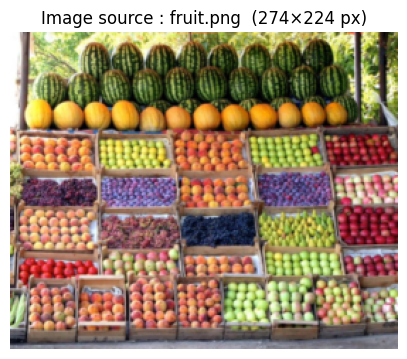

In [3]:
import urllib.request
from PIL import Image
import matplotlib.pyplot as plt

IMAGE_NAME = 'fruit.png'
IMAGE_PATH = f'sinfusion/images/{IMAGE_NAME}'

os.makedirs('sinfusion/images', exist_ok=True)

if not os.path.exists(IMAGE_PATH):
    url = f'https://raw.githubusercontent.com/yanivnik/sinfusion-code/main/images/{IMAGE_NAME}'
    urllib.request.urlretrieve(url, IMAGE_PATH)
    print(f"Image téléchargée : {IMAGE_PATH}")
else:
    print(f"Image déjà présente : {IMAGE_PATH}")

# Afficher l'image source
img = Image.open(IMAGE_PATH)
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title(f'Image source : {IMAGE_NAME}  ({img.width}×{img.height} px)')
plt.axis('off')
plt.show()

## 3. Entraînement SinFusion

Entraîne un DDPM sur l'image source.  
Le checkpoint est sauvegardé dans `sinfusion/lightning_logs/fruit.png/fruit_teacher/checkpoints/last.ckpt`.

> `--diffusion_timesteps 50` = valeur du papier (rapide à tester).  
> Pour un entraînement complet, le code original tourne 50 000 steps — ici on peut réduire via `max_steps` si besoin mais on laisse le défaut du papier.

In [4]:
%%time
!cd sinfusion && python main.py \
    --task image \
    --image_name fruit.png \
    --run_name fruit_teacher \
    --diffusion_timesteps 50 \
    --network_depth 16 \
    --network_filters 64

available_gpus=0
diffusion_timesteps=50
frame_diff=1
image_name=fruit.png
initial_lr=0.0002
interpolation_rate=4
network_depth=16
network_filters=64
output_dir=outputs
output_video_len=100
project_name=SinFusion
run_name=fruit_teacher
sample_count=1
sample_size=None
start_frame_index=None
task=image
/workspace/.miniconda3/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/accelerator_connector.py:478: LightningDeprecationWarning: Setting `Trainer(gpus=1)` is deprecated in v1.7 and will be removed in v2.0. Please use `Trainer(accelerator='gpu', devices=1)` instead.
  rank_zero_deprecation(
/workspace/.miniconda3/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/accelerator_connector.py:589: LightningDeprecationWarning: The Trainer argument `auto_select_gpus` has been deprecated in v1.9.0 and will be removed in v2.0.0. Please use the function `pytorch_lightning.accelerators.find_usable_cuda_devices` instead.
  rank_zero_deprecation(
Auto select gpus: [0]
Tr

## 4. TensorBoard — courbe de loss

In [5]:
%load_ext tensorboard
%tensorboard --logdir sinfusion/lightning_logs --port 6006

## 5. Génération d'échantillons

In [6]:
%%time
!cd sinfusion && python sample.py \
    --task image \
    --image_name fruit.png \
    --run_name fruit_teacher \
    --sample_count 8 \
    --diffusion_timesteps 50 \
    --network_depth 16 \
    --output_dir ../outputs

available_gpus=0
diffusion_timesteps=50
frame_diff=1
image_name=fruit.png
initial_lr=0.0002
interpolation_rate=4
network_depth=16
network_filters=64
output_dir=../outputs
output_video_len=100
project_name=SinFusion
run_name=fruit_teacher
sample_count=8
sample_size=None
start_frame_index=None
task=image
Sample directory: ../outputs/fruit.png/fruit_teacher/
100%|█████████████████████████████████████████████| 1/1 [00:16<00:00, 16.30s/it]
CPU times: user 484 ms, sys: 183 ms, total: 667 ms
Wall time: 35 s


## 6. Visualisation des résultats

8 fichier(s) trouvé(s) dans outputs/fruit.png/fruit_teacher


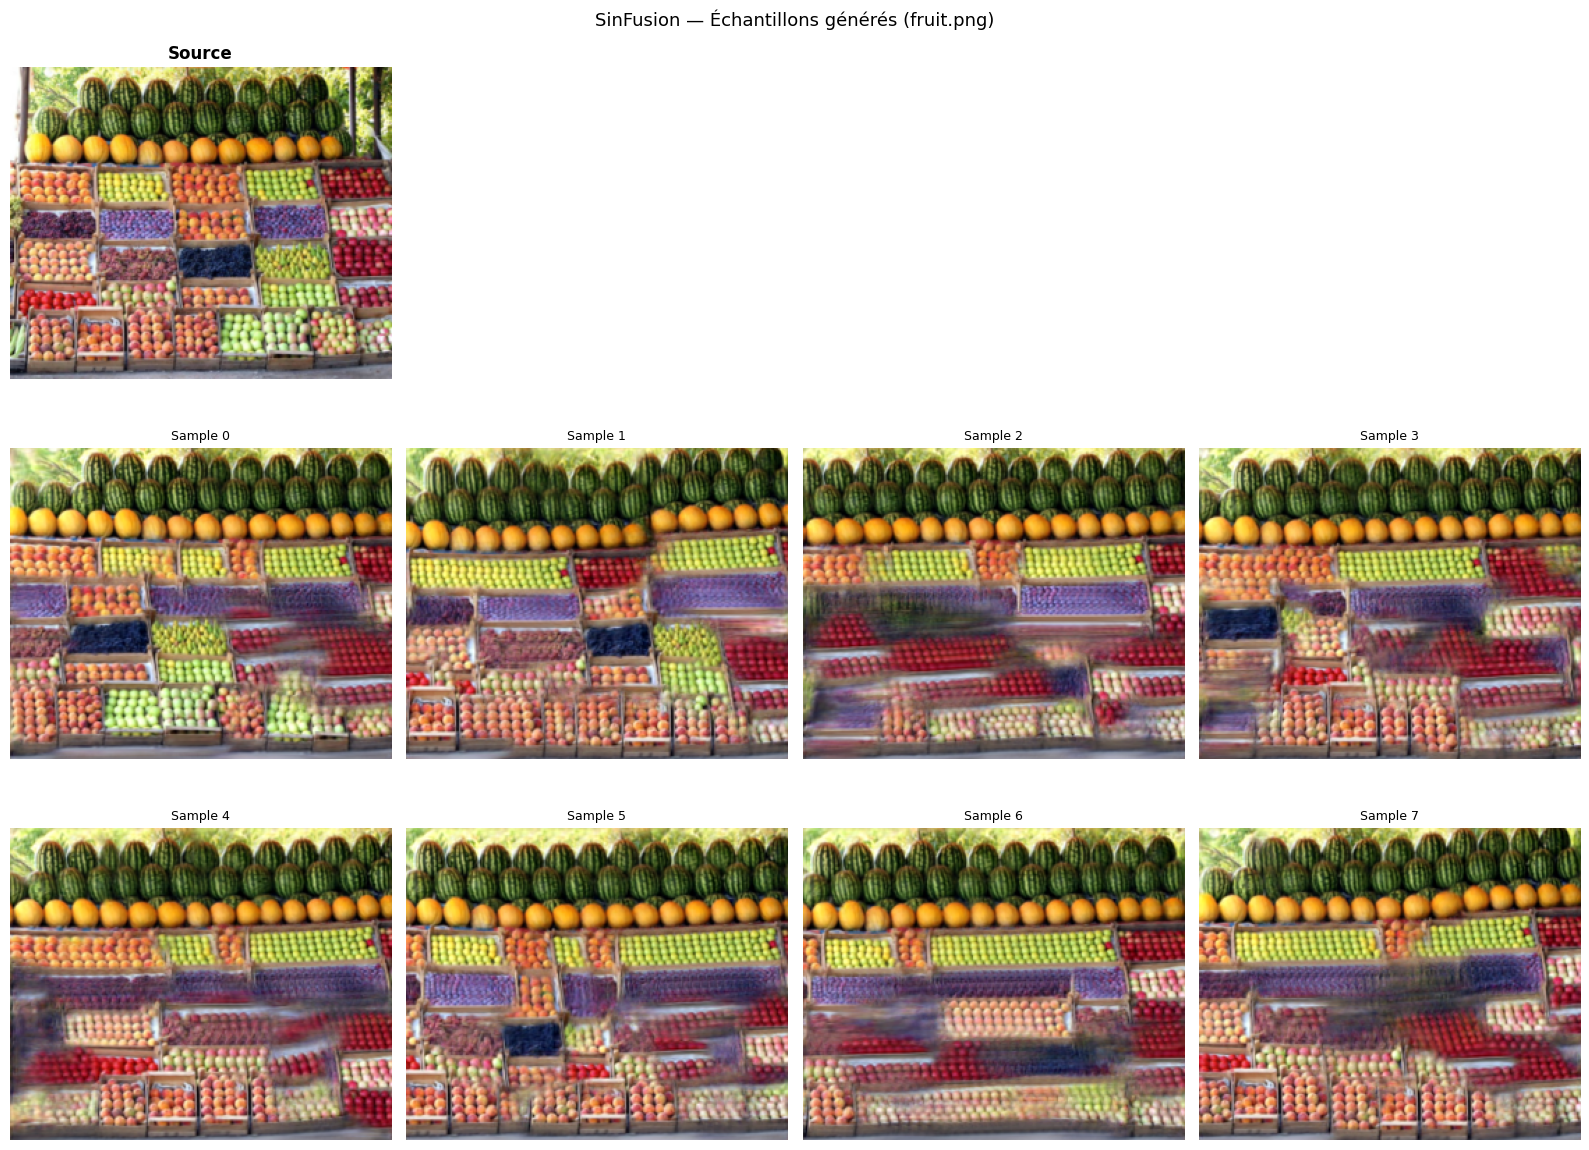

In [7]:
import glob
import numpy as np

OUTPUT_DIR = 'outputs/fruit.png/fruit_teacher'

# Récupérer tous les fichiers générés
sample_files = sorted(glob.glob(f'{OUTPUT_DIR}/*.png'))
print(f"{len(sample_files)} fichier(s) trouvé(s) dans {OUTPUT_DIR}")

if not sample_files:
    print("Aucun échantillon trouvé — vérifier que la cellule 5 s'est bien exécutée.")
else:
    n = len(sample_files)
    n_cols = min(4, n)
    n_rows = (n + n_cols - 1) // n_cols

    fig, axes = plt.subplots(1 + n_rows, n_cols, figsize=(4 * n_cols, 4 * (1 + n_rows)))
    axes = np.array(axes).reshape(1 + n_rows, n_cols)

    # Ligne 0 : image source
    axes[0, 0].imshow(img)
    axes[0, 0].set_title('Source', fontweight='bold')
    axes[0, 0].axis('off')
    for j in range(1, n_cols):
        axes[0, j].axis('off')

    # Lignes suivantes : échantillons générés
    for i, path in enumerate(sample_files):
        r, c = divmod(i, n_cols)
        axes[r + 1, c].imshow(Image.open(path))
        axes[r + 1, c].set_title(f'Sample {i}', fontsize=9)
        axes[r + 1, c].axis('off')
    for i in range(n, n_rows * n_cols):
        r, c = divmod(i, n_cols)
        axes[r + 1, c].axis('off')

    fig.suptitle('SinFusion — Échantillons générés (fruit.png)', fontsize=13)
    plt.tight_layout()
    plt.show()